In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Choose which regions to plot (one figure per region)
regions = ["region_lower_byrd", "region_mid_byrd", "region_upper_byrd"]
models = ["dfNN", "dfGP", "dfGPcm", "dfNGP", "PINN", "GP"]

MEAN_ROW_IDX = 0
STD_ROW_IDX = 1

# SIM RMSE

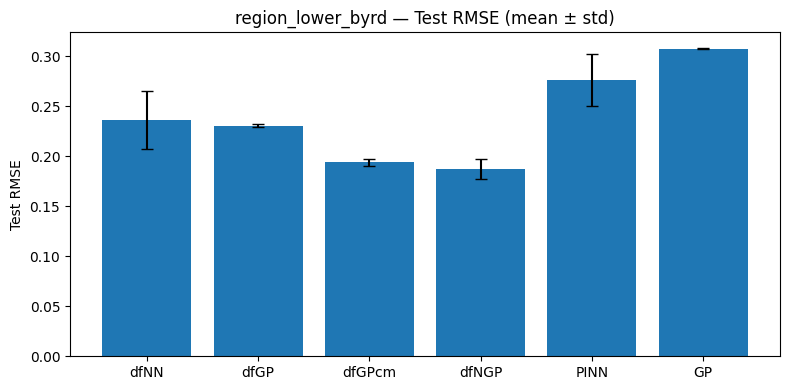

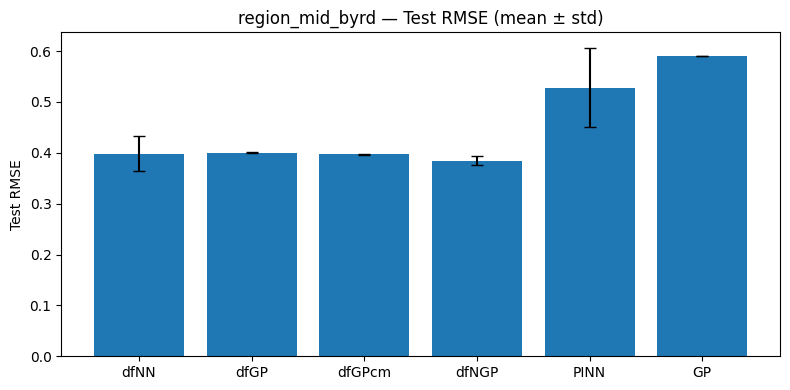

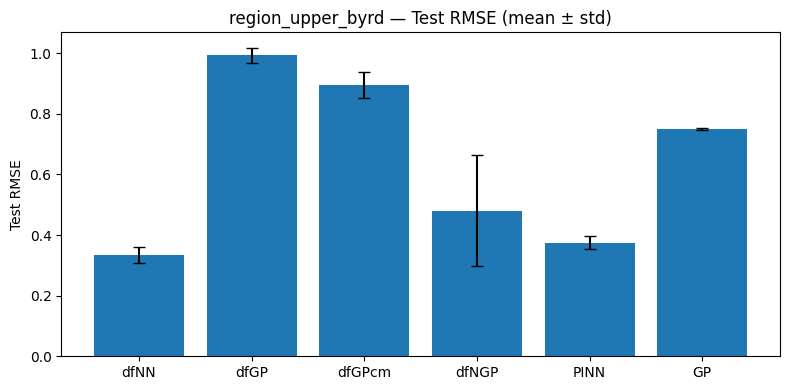

In [4]:
# If your CSVs put mean in row 0 and std in row 1 (same column name), set these:
METRIC_COL = "Test RMSE"

for region in regions:
    rows = []
    for m in models:
        path = os.path.join(m, f"{region}_{m}_metrics_summary.csv")
        if not os.path.exists(path):
            # skip missing results gracefully
            print(f"Missing: {path}")
            continue
        df = pd.read_csv(path)
        mean_rmse = df[METRIC_COL].iloc[MEAN_ROW_IDX]
        std_rmse  = df[METRIC_COL].iloc[STD_ROW_IDX]
        rows.append({"model": m, "mean": mean_rmse, "std": std_rmse})

    if not rows:
        continue

    plot_df = pd.DataFrame(rows).set_index("model").loc[models]  # keep consistent order

    # --- Bar chart with error bars ---
    plt.figure(figsize = (8, 4))
    x = np.arange(len(plot_df))
    plt.bar(x, plot_df["mean"], yerr=plot_df["std"], capsize=4)
    plt.xticks(x, plot_df.index, rotation=0)
    plt.ylabel("Test RMSE")
    plt.title(f"{region} — Test RMSE (mean ± std)")
    plt.tight_layout()
    plt.show()

# Average

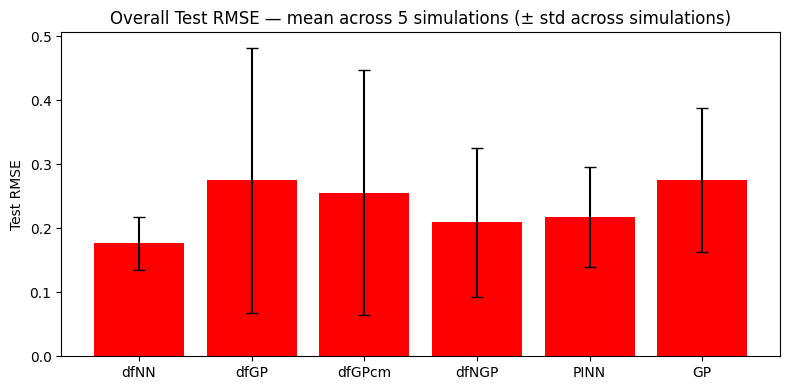

In [5]:
METRIC_COL = "Test RMSE"

# Collect per-simulation means for each model
per_model_sim_means = {m: [] for m in models}

for region in regions:
    for m in models:
        path = os.path.join(m, f"{region}_{m}_metrics_summary.csv")
        if not os.path.exists(path):
            print(f"Missing: {path}")
            continue

        df = pd.read_csv(path)

        # If each CSV has raw per-run rows, use mean() across runs:
        sim_mean = df[METRIC_COL].mean()

        # If instead your CSV has two rows (mean, std), use:
        # sim_mean = df[METRIC_COL].iloc[0]

        per_model_sim_means[m].append(sim_mean)

# Build overall summary: mean across simulations (+ std across simulations)
rows = []
for m in models:
    vals = per_model_sim_means[m]
    if len(vals) == 0:
        continue
    overall_mean = float(np.mean(vals))
    overall_std  = float(np.std(vals, ddof=1))  # std across simulations
    rows.append({"model": m, "mean": overall_mean, "std": overall_std})

summary = pd.DataFrame(rows).set_index("model").loc[[m for m in models if m in [r["model"] for r in rows]]]

# --- Single bar chart: mean across 5 simulations (error = std across simulations) ---
plt.figure(figsize=(8, 4))
x = np.arange(len(summary))
plt.bar(x, summary["mean"], yerr = summary["std"], capsize = 4, color = "red")
plt.xticks(x, summary.index, rotation=0)
plt.ylabel("Test RMSE")
plt.title("Overall Test RMSE — mean across 5 simulations (± std across simulations)")
plt.tight_layout()
plt.show()

# NLL

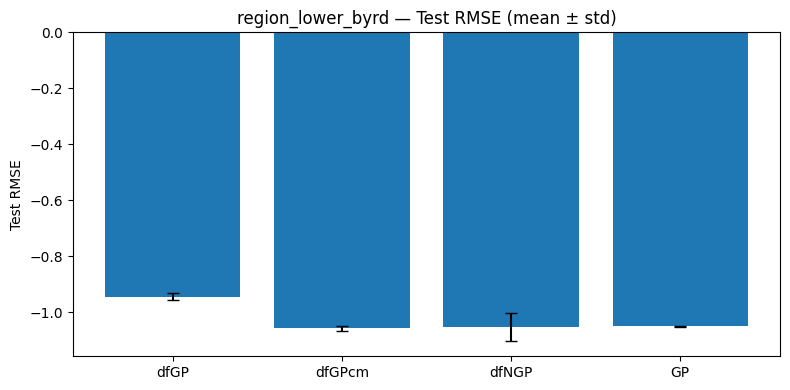

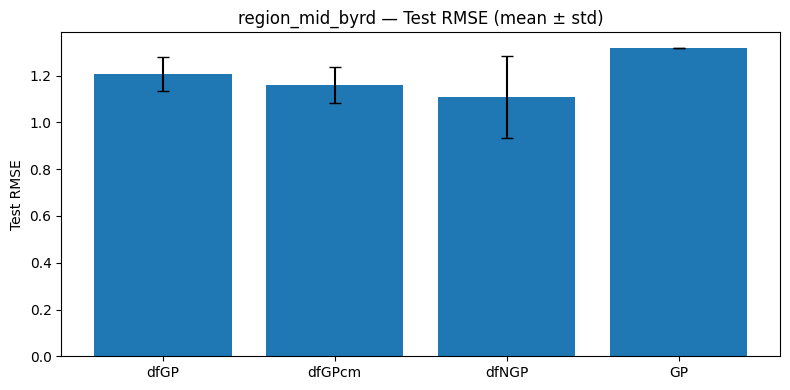

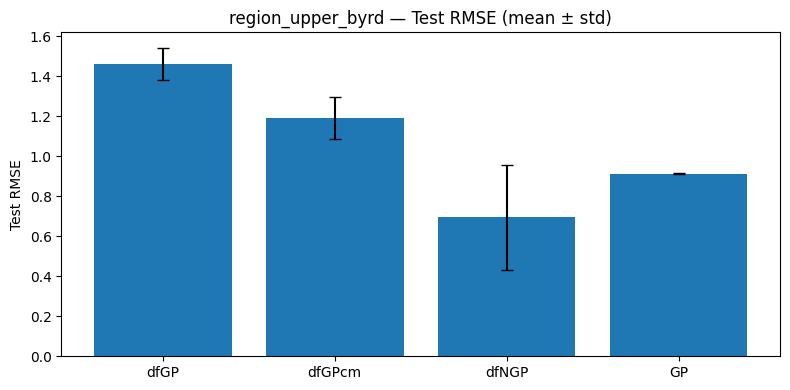

In [8]:
# If your CSVs put mean in row 0 and std in row 1 (same column name), set these:
METRIC_COL = "Test NLL"

# Only for probabilistic models
models = ["dfGP", "dfGPcm", "dfNGP", "GP"]

for region in regions:
    rows = []
    for m in models:
        path = os.path.join(m, f"{region}_{m}_metrics_summary.csv")
        if not os.path.exists(path):
            # skip missing results gracefully
            print(f"Missing: {path}")
            continue
        df = pd.read_csv(path)
        mean_rmse = df[METRIC_COL].iloc[MEAN_ROW_IDX]
        std_rmse  = df[METRIC_COL].iloc[STD_ROW_IDX]
        rows.append({"model": m, "mean": mean_rmse, "std": std_rmse})

    if not rows:
        continue

    plot_df = pd.DataFrame(rows).set_index("model").loc[models]  # keep consistent order

    # --- Bar chart with error bars ---
    plt.figure(figsize=(8, 4))
    x = np.arange(len(plot_df))
    plt.bar(x, plot_df["mean"], yerr=plot_df["std"], capsize=4)
    plt.xticks(x, plot_df.index, rotation=0)
    plt.ylabel("Test RMSE")
    plt.title(f"{region} — Test RMSE (mean ± std)")
    plt.tight_layout()
    plt.show()
